In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
df = sns.load_dataset("iris")

print("=" * 45)
print("DATASET SHAPE:", df.shape)
print("=" * 45)
print("\n📌 Column Names:", df.columns.tolist())
print("\n📌 First 5 Rows:")
display(df.head())

print("\n📌 Data Types & Null Values:")
display(df.info())

print("\n📌 Descriptive Statistics:")
display(df.describe().round(2))

print("\n📌 Class Distribution:")
display(df["species"].value_counts())

print("\n📌 Missing Values:")
print(df.isnull().sum())

DATASET SHAPE: (150, 5)

📌 Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

📌 First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



📌 Data Types & Null Values:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


None


📌 Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



📌 Class Distribution:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


📌 Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


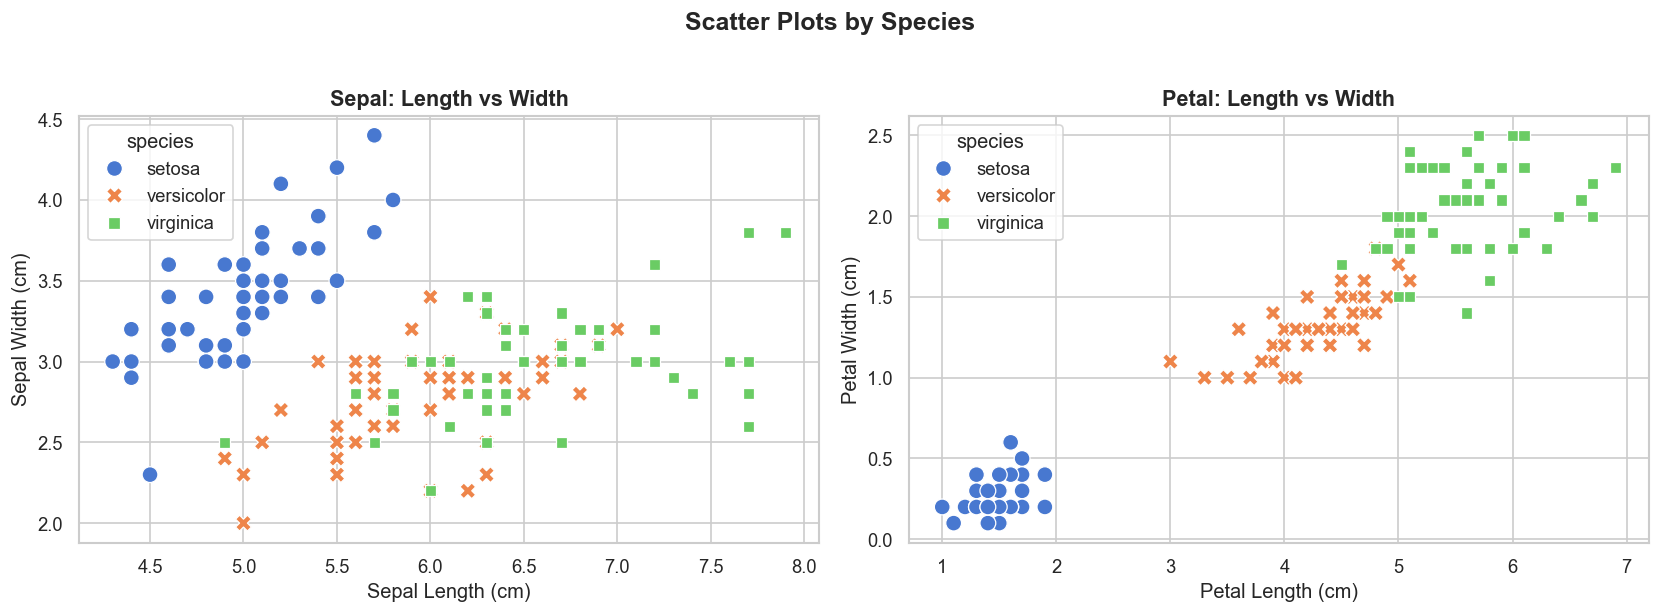

✅ Scatter plots saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="sepal_length", y="sepal_width",
                hue="species", style="species", s=90, ax=axes[0])
axes[0].set_title("Sepal: Length vs Width", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")

sns.scatterplot(data=df, x="petal_length", y="petal_width",
                hue="species", style="species", s=90, ax=axes[1])
axes[1].set_title("Petal: Length vs Width", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.suptitle("Scatter Plots by Species", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("scatter_plots.png")
plt.show()
print("✅ Scatter plots saved!")

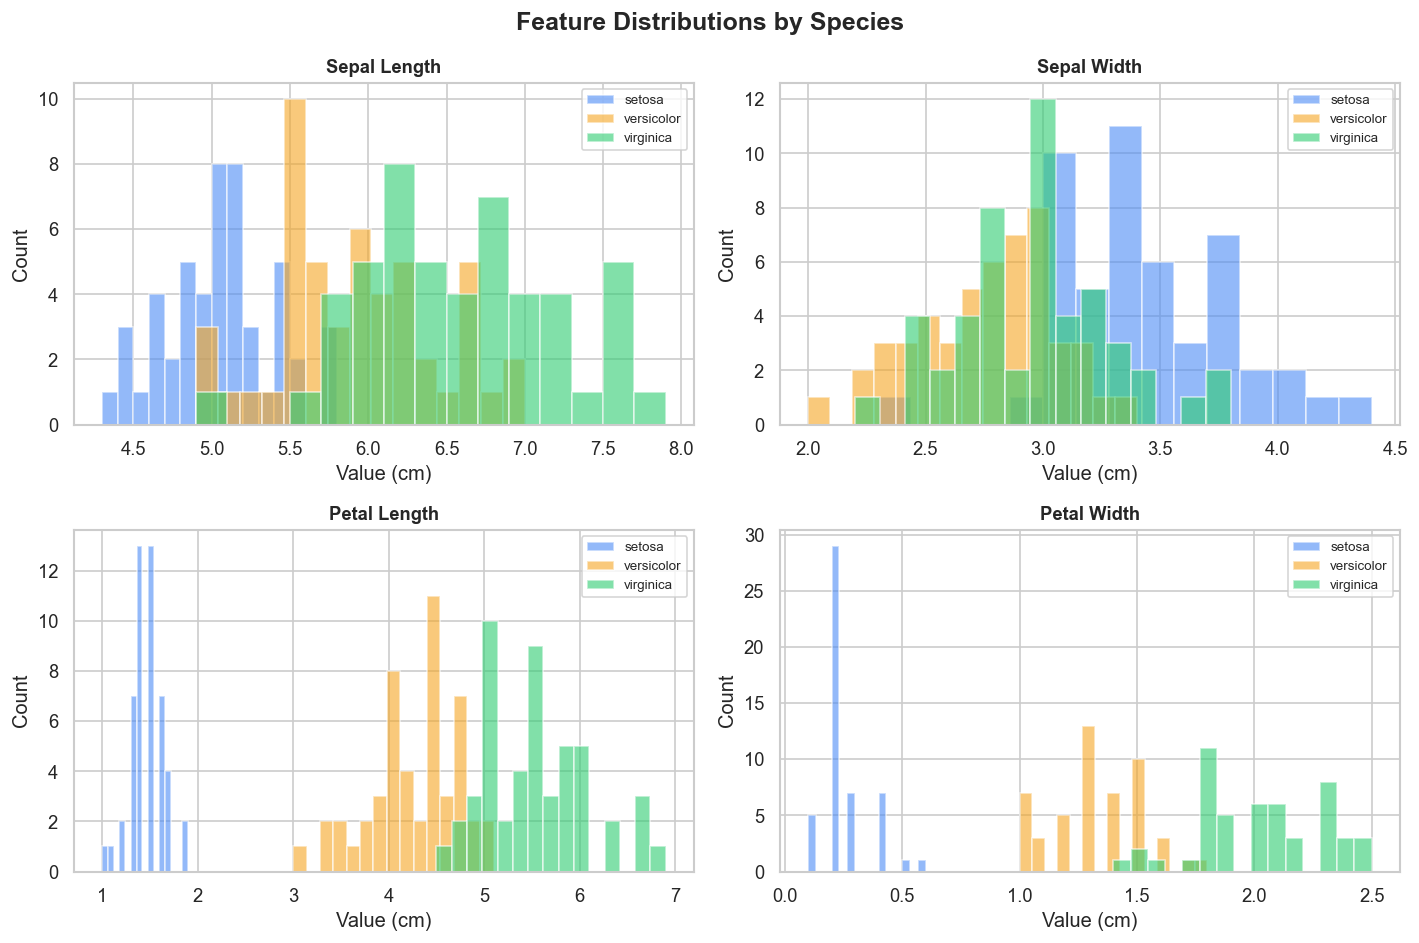

✅ Histograms saved!


In [4]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
colors   = {"setosa": "#4C8BF5", "versicolor": "#F5A623", "virginica": "#2ECC71"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    for species, grp in df.groupby("species"):
        ax.hist(grp[feat], bins=15, alpha=0.6,
                label=species, color=colors[species], edgecolor="white")
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Value (cm)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Species", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("histograms.png")
plt.show()
print("✅ Histograms saved!")

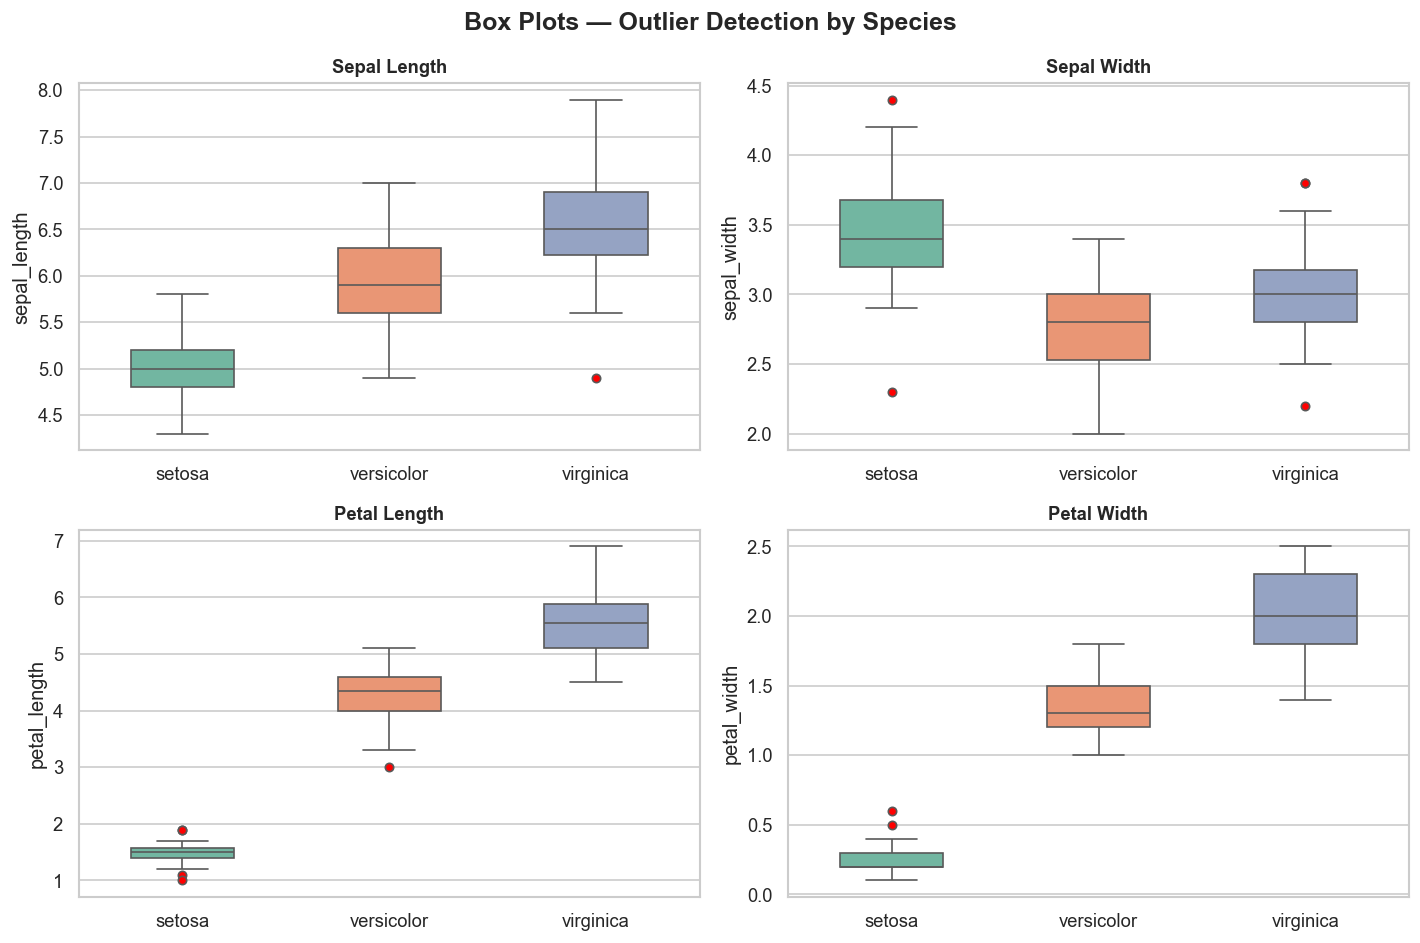

✅ Box plots saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="species", y=feat, palette="Set2",
                width=0.5, ax=ax,
                flierprops=dict(marker="o", markerfacecolor="red", markersize=5))
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Box Plots — Outlier Detection by Species", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplots.png")
plt.show()
print("✅ Box plots saved!")

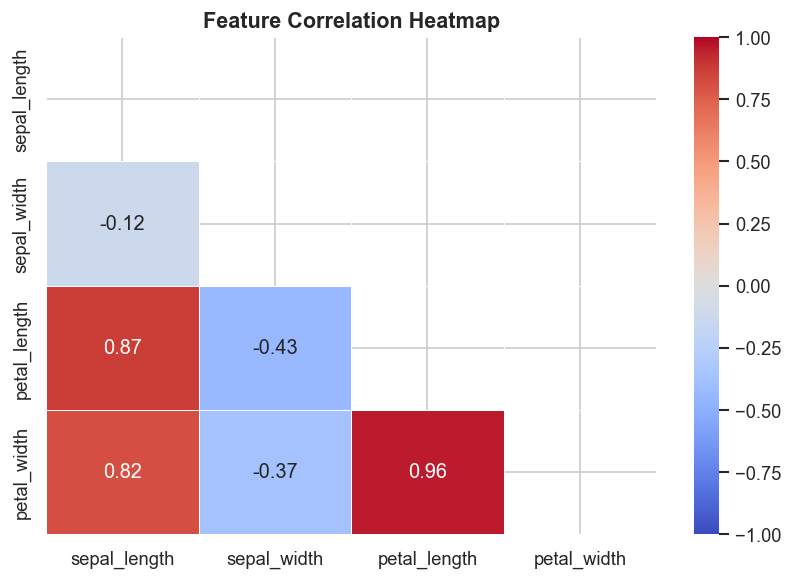

✅ Heatmap saved!


In [6]:
plt.figure(figsize=(7, 5))
corr = df[features].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap="coolwarm", mask=mask,
            vmin=-1, vmax=1, linewidths=0.5, fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()
print("✅ Heatmap saved!")

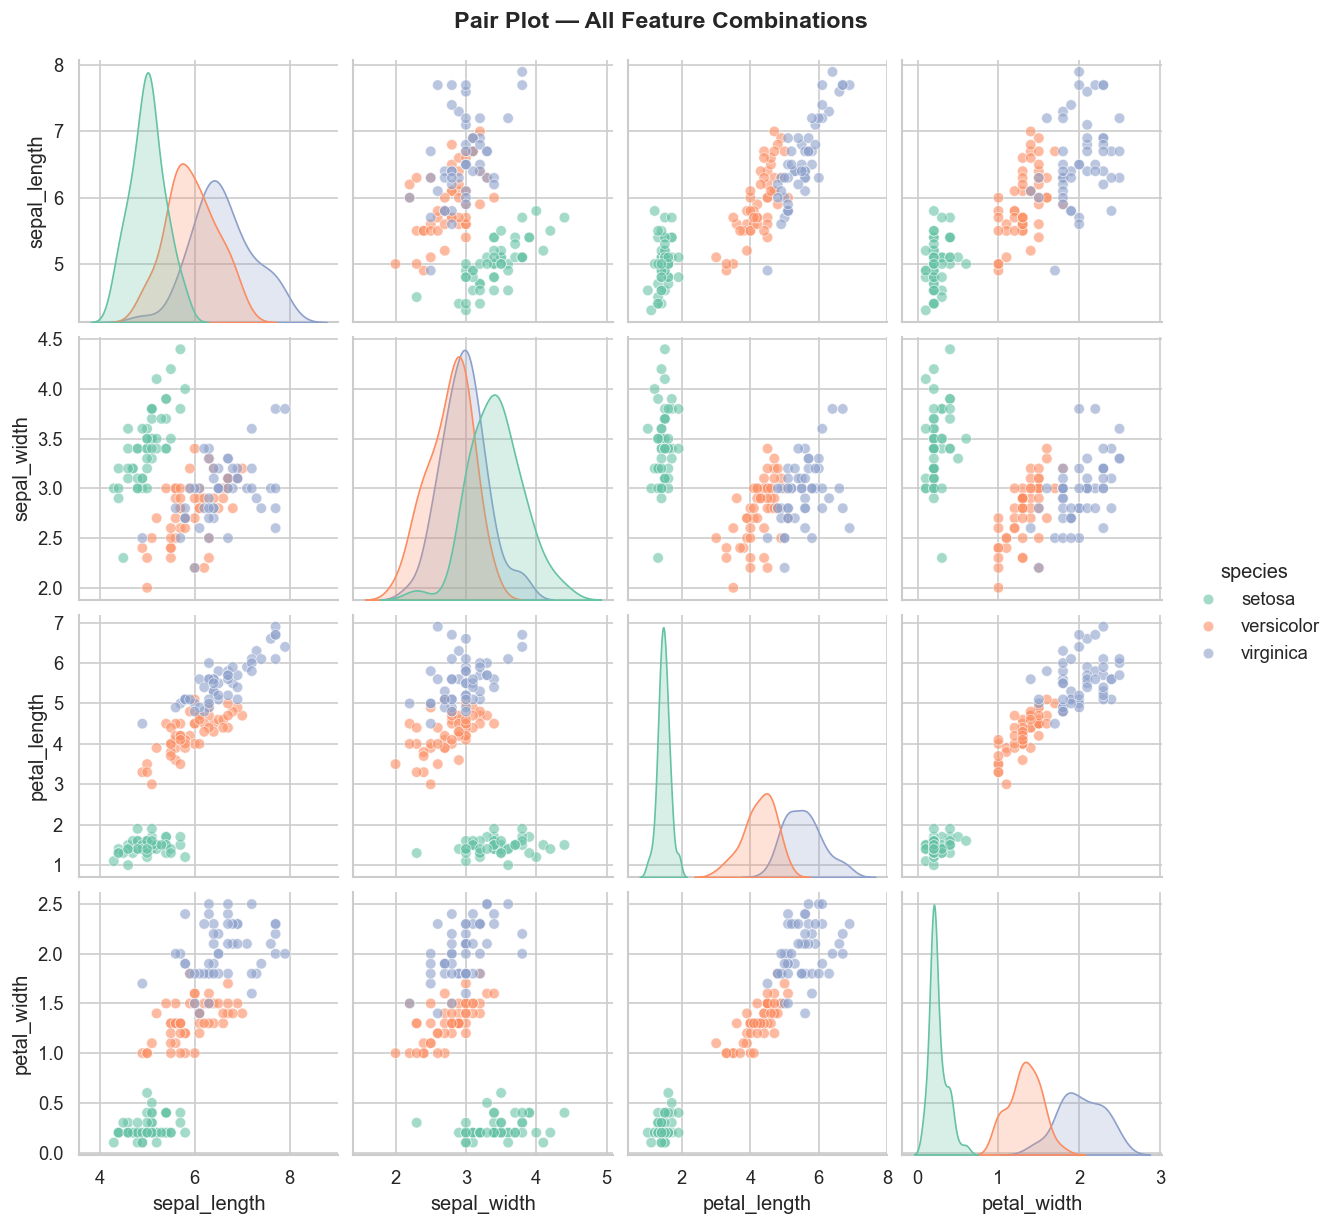

✅ Pair plot saved!


In [7]:
pair = sns.pairplot(df, hue="species", diag_kind="kde",
                    plot_kws={"alpha": 0.6, "s": 40},
                    palette="Set2")
pair.fig.suptitle("Pair Plot — All Feature Combinations",
                  y=1.02, fontsize=14, fontweight="bold")
plt.savefig("pairplot.png")
plt.show()
print("✅ Pair plot saved!")

## 🔍 Key Findings — Task 1

| # | Finding |
|---|---------|
| 1 | **Setosa** is clearly separable from the other two species using petal features alone |
| 2 | **Petal length & width** are highly correlated (r = 0.96) — strongest predictors |
| 3 | **Sepal width** has the most overlap between species — least useful for classification |
| 4 | Dataset is **clean** — no missing values, no major outliers detected |
| 5 | **Virginica** has the largest measurements across all four features on average |